# The whole of k-space in one shot

A gradient echo acquires one line per excitation. An **echo-planar** readout acquires all of them
from one, by reversing the readout gradient after every line and stepping `ky` with a **blip** in
between. That is 128 lines in 90 ms instead of 128 TRs, and everything interesting about it follows
from one fact:

> **The lobes alternate sign.** Anything that displaces the two polarities differently in `k` — a
> gradient delay, an eddy current, a constant off-resonance — becomes a modulation of period two
> along `ky`, and a period-two modulation is a **replica of the object at half the field of view**.

So the sequence itself has to be exactly symmetric, or the ghost
[`02`](02_simulate_and_reconstruct.ipynb) measures is the sequence's own rather than the scanner's.
`EPI2D` buys that with two rules, and this notebook builds them:

| | |
|---|---|
| **Rule 1** | the sampling window is **exactly centred** in its lobe: `T = 2·guard + N·dwell`, with equality |
| **Rule 2** | the blip is **centred on the seam** — the readout's zero crossing — and `sc.barrier()` is forced there |

**Two passes**, as in [`../se_2d/`](../se_2d/01_build.ipynb): the readout on its own with every
number measured off it, then `GREEPI2D` — excitation, train, and a spoiler that also rewinds —
written out. `EPI2D` ships; `GREEPI2D` has one consumer, which is this notebook, and stays here.

**Output:** eight `.seq` files and `seq/gre_epi_2d_nominal.npz`. **Needs nothing but
`seqcraft`.**

## 0. The scanner, and the protocol

Three numbers are not free choices here either.

| | |
|---|---|
| **180 T/m/s, where the rest of the repository uses 130–150** | an EPI lives on its ramps. At 150 the reference protocol will not build with ramp sampling and partial echo together, so the slew rate is printed against a PNS model below rather than assumed |
| **2.5 µs dwell at `oversampling=2`** | 1562 Hz per *reconstructed* pixel. §3 scans the alternatives: it is the shortest dwell at which all five modes build |
| **`oversampling=2`** | free — twice the samples at half the dwell is the same sampling duration — and without it a ramp-sampled flat top is under-sampled against the grid it is reconstructed onto. [`02`](02_simulate_and_reconstruct.ipynb) §2 measures that |

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (220.0, 220.0)          # (x, y)   -- readout, blip
MATRIX = (128, 128)              # (nx, ny) -- readout, blip
THICKNESS_MM = 5.0
DWELL_S = 2.5e-6                 # the ADC dwell; the scan in section 3 is why this one
OVERSAMPLING = 2                 # samples per reconstructed pixel along the readout
EXCITE_DURATION_S = 2.0e-3
SPOIL_CYCLES = 4.0
RF_SPOIL_DEG = 117.0             # the carrier increment; section 8 is why a spoiler is not enough
DUMMY_SHOTS = 2                  # every acquisition's run-in -- section 8 measures why
TR_S = 1.0
TE_S = 50.0e-3                   # **one echo time for every imaging file** -- section 8
NAIVE_TR_S = 0.2                 # the short TR section 8 measures against, and nothing else
ACS_LINES = 32                   # the calibration band, for the accelerated scans
REFERENCE_FLIP_DEG = 25.0        # the calibration scan's flip -- section 8
REFERENCE_TR_S = 0.05            # one calibration line per excitation, so the TR can be short
REFERENCE_DUMMIES = 40           # how many that flip needs to reach its steady state

NX, NY = MATRIX
CENTER_LINE = NY // 2
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]
grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def compiled(tree, name='probe', definitions=None):
    """Compile, keeping the warnings so a cell can assert on them instead of hiding them."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        seq = sc.compile(tree, opts, name=name, definitions=definitions)
    return seq, [str(w.message) for w in caught]


def gradient_kinds(seq, axis):
    """Which pulseq representation `axis` came out as.  A split lobe stops being a ``trap``."""
    return sorted({getattr(g, 'type', '?') for i in range(1, len(seq.block_events) + 1)
                   for g in (getattr(seq.get_block(i), axis, None),) if g is not None})


print(f'{NX} x {NY} over {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'dk {DK_X:.3f} 1/m on both axes, centre line {CENTER_LINE}')
print(f'{opts.max_grad / opts.gamma * 1e3:.0f} mT/m at '
      f'{opts.max_slew / opts.gamma:.0f} T/m/s, {opts.adc_dead_time * 1e6:.0f} us receive dead time')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128 over 220 x 220 mm, 5 mm slice
dk 4.545 1/m on both axes, centre line 64
40 mT/m at 180 T/m/s, 10 us receive dead time


---
# Pass 1 — the readout

## 1. Rule 1, and why it is an equality

Write `T` for the lobe duration, `g` for the un-sampled guard at each end, `N` for the sample
count and `τ` for the dwell:

$$T \;=\; 2g + N\tau \qquad\text{exactly, not ``at least''}$$

A trapezoid is symmetric about its own midpoint, so its running area satisfies
$A(t) + A(T-t) = A_\text{total}$. Sample $i$ of a forward lobe is at $t_i = g + (i+\tfrac12)\tau$
and sample $N{-}1{-}i$ of the reverse lobe that follows is at $t_{N-1-i} = g + (N-i-\tfrac12)\tau$.
Their sum is $2g + N\tau$, which equals $T$ **only when the window is centred** — and only then do
the two polarities sample the *same* set of `k` positions, in opposite order.

Write the lobe the natural way instead — flat top rounded up onto the gradient raster, slack left
after the last sample, which is exactly what `CartesianLine` correctly does for a *line* — and the
two polarities sample grids up to half a gradient raster apart. That is an N/2 ghost the sequence
made itself, it is invisible in the block structure, and against a symmetric phantom the image
still looks like an image.

In [2]:
epi = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX,
                       dwell_s=DWELL_S, oversampling=OVERSAMPLING)

print(f'{epi.num_samples} samples at {epi.dwell_s * 1e9:.0f} ns '
      f'= {epi.bandwidth_hz_px:.0f} Hz per reconstructed pixel')
print(f'echo spacing {epi.echo_spacing_s * 1e6:.0f} us '
      f'= 2 x {epi.guard_s * 1e6:.1f} us guard + {epi.num_samples * epi.dwell_s * 1e6:.1f} us of '
      f'samples')
print(f'residual {abs(2 * epi.guard_s + epi.num_samples * epi.dwell_s - epi.echo_spacing_s):.1e} s'
      f'   <- Rule 1, and it is an equality')
print(f'peak {epi.readout_amplitude_hz_m / opts.gamma * 1e3:.2f} mT/m, blip '
      f'{epi.blip_duration_s * 1e6:.0f} us, train {NY * epi.echo_spacing_s * 1e3:.2f} ms')
print()

# Over several dwells, because whether the mistake shows *at all* is a property of the protocol --
# which is exactly why the fix has to be structural rather than something a build notebook checks.
def window_error(made, *, centred):
    """Worst |t_i + t_(N-1-i) - T| over the window, in seconds.  Zero iff the window is centred."""
    offsets = (np.arange(made.num_samples) + 0.5) * made.dwell_s
    sample_time = made.num_samples * made.dwell_s
    slack = float(np.ceil(sample_time / opts.grad_raster_time) * opts.grad_raster_time
                  - sample_time)
    times = made.guard_s + offsets - (0.0 if centred else slack / 2)
    return np.abs(times + times[::-1] - made.echo_spacing_s).max(), slack


print(f'{"dwell":>8s} {"N*dwell":>10s} {"slack":>8s} {"centred":>10s} {"slack at one end":>18s}')
for dwell in (2.0e-6, 2.5e-6, 3.0e-6, 3.5e-6):
    made = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=dwell,
                            oversampling=OVERSAMPLING)
    good, slack = window_error(made, centred=True)
    bad, _ = window_error(made, centred=False)
    print(f'{made.dwell_s * 1e9:7.0f}n {made.num_samples * made.dwell_s * 1e6:9.1f}u '
          f'{slack * 1e6:7.1f}u {good * 1e9:9.1f}n {bad * 1e9:17.1f}n')

print('\nThe reference protocol is the first row of a trap rather than an example of one: its')
print('sampling duration lands exactly on the 10 us gradient raster, so there is no slack to')
print('misplace and the *wrong* construction happens to come out right.  Move the dwell one')
print('quantum and it does not.')
print('That is the argument for the equality being structural.  A check that passed on the')
print('protocol it was written against would have said nothing about the next one, and the')
print('symptom is an N/2 ghost indistinguishable from the one 02 exists to measure.')

256 samples at 2500 ns = 1562 Hz per reconstructed pixel
echo spacing 700 us = 2 x 30.0 us guard + 640.0 us of samples
residual 2.2e-19 s   <- Rule 1, and it is an equality
peak 24.69 mT/m, blip 60 us, train 89.60 ms

   dwell    N*dwell    slack    centred   slack at one end
   2000n     512.0u     8.0u       0.0n            8000.0n
   2500n     640.0u     0.0u       0.0n               0.0n
   3000n     768.0u     2.0u       0.0n            2000.0n
   3500n     896.0u     4.0u       0.0n            4000.0n

The reference protocol is the first row of a trap rather than an example of one: its
sampling duration lands exactly on the 10 us gradient raster, so there is no slack to
misplace and the *wrong* construction happens to come out right.  Move the dwell one
quantum and it does not.
That is the argument for the equality being structural.  A check that passed on the
protocol it was written against would have said nothing about the next one, and the
symptom is an N/2 ghost indistinguish

### `k = 0` is a sample, not a moment

Which sample it is depends on the polarity, and that expression's wrong branch is an N/2 ghost —
so `echo_sample` is a method rather than something five call sites each write out.

In [3]:
tree = sc.LogicBlock('readout').add(0.0, epi(lines=range(NY)))
with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    k = sc.kspace(tree, opts)
kx = k['k_adc'].reshape(3, NY, epi.num_samples)[0]
t_adc = k['t_adc'].reshape(NY, epi.num_samples)

echo = max(abs(kx[n, epi.echo_sample(n)]) for n in range(NY))
mirror = max(np.abs(kx[n] - (epi.k_read_per_m if epi.polarity(n) > 0
                             else epi.k_read_per_m[::-1])).max() for n in range(NY))
timing = max(abs(t_adc[n, epi.echo_sample(n)] - epi.time_to_echo(n)) for n in range(NY))

print(f'polarity(0..3)     {[epi.polarity(n) for n in range(4)]}')
print(f'echo_sample(0..3)  {[epi.echo_sample(n) for n in range(4)]}')
print()
print(f'|kx| at the echo sample, worst of {NY} echoes   {echo:.2e} 1/m   (dk = {DK_X:.3f})')
print(f'k_read_per_m against what plays, per sample      {mirror:.2e} 1/m')
print(f'time_to_echo against the true ADC sample time    {timing * 1e12:.0f} ps')
print()
print('Measured on the *compiled* waveform integrated at the true sample times, which is not the')
print('arithmetic that produced it -- k_read_per_m agreeing with itself would prove nothing.')

polarity(0..3)     [1, -1, 1, -1]
echo_sample(0..3)  [128, 127, 128, 127]

|kx| at the echo sample, worst of 128 echoes   2.02e-10 1/m   (dk = 4.545)
k_read_per_m against what plays, per sample      2.05e-10 1/m
time_to_echo against the true ADC sample time    0 ps

Measured on the *compiled* waveform integrated at the true sample times, which is not the
arithmetic that produced it -- k_read_per_m agreeing with itself would prove nothing.


## 2. Rule 2 — the blip on the zero crossing, and why the barrier is not optional

The blip belongs where the readout gradient passes through zero, for two independent reasons:
it is where the two axes ask least of the amplifier together, and a **centred** blip needs only
`b/2` of guard at each side instead of a whole `b`.

But a centred blip *straddles* the block boundary the compiler has to cut between two ADCs, and
**there is no instant in that gap which cuts nothing**: the gap is
`[seam − g + t_dead, seam]`, every instant strictly inside it is in the readout lobe's fall ramp,
and the seam itself is inside the blip. Left to choose, the compiler takes the midpoint of the gap
and splits **every readout lobe in the train**.

That version compiles. It passes every k-space check in the cell above. It simulates correctly.
The only report of it is a `merge` warning naming the *readout* axis — which is why the cell below
builds it, rather than describing it.

The third row is the placement this design rejected, kept as a measurement rather than as a
paragraph. Both variants reach into `EPI2D`'s internals on purpose: they are designs the module
deliberately does not offer.

In [4]:
class NoBarrier(sc.modules.EPI2D):
    """Rule 2 with the barrier dropped: the blip is still centred, the compiler still has to cut."""

    def _seam(self, out, seam_s, step):
        if step:
            out.add(seam_s - self.blip_duration_s / 2, self._blip_for(step))


class EndsAtSeam(sc.modules.EPI2D):
    """The rejected placement: the blip inside one lobe's fall ramp, so it straddles nothing."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # A blip that plays entirely inside one lobe has to fit in the guard *whole* rather than in
        # half.  That is the placement's whole cost, so re-run the three steps that read the guard.
        self._guard_min_s = max(self.blip_duration_s, float(self.opts.adc_dead_time))
        self.gx, self.adc, self.guard_s = self._design_lobe()
        self._gx_reverse = sc.events.derive(pp.scale_grad(self.gx, -1.0))
        self.echo_spacing_s = float(pp.calc_duration(self.gx))
        self._echo_in_lobe_s = float(self.adc.delay) + (self.pre_echo_samples + 0.5) * self.dwell_s
        self.k_read_per_m = self._sampled_k()
        self.pe, self.winder_s, self._prephaser = self._design_prephasers(None)

    def _seam(self, out, seam_s, step):
        if step:
            out.add(seam_s - self.blip_duration_s, self._blip_for(step))


print(f'{"placement":24s} {"esp":>6s} {"guard":>7s} {"blocks":>7s} {"gx":>16s} {"gy":>16s}  merge')
placements = (('centred + barrier', sc.modules.EPI2D), ('centred, no barrier', NoBarrier),
              ('ends at the seam', EndsAtSeam))
spacings = {}
for label, cls in placements:
    probe = cls(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                oversampling=OVERSAMPLING)
    seq, notes = compiled(sc.LogicBlock('probe').add(0.0, probe(lines=range(NY))))
    spacings[label] = probe.echo_spacing_s
    merges = [m for m in notes if 'gradient merge' in m]
    counted = sum(int(m.split()[0]) for m in merges)
    axes = ','.join(sorted({part.split(')')[0] for m in merges
                            for part in m.split('(axis ')[1:]}))
    print(f'{label:24s} {probe.echo_spacing_s * 1e6:5.0f}u {probe.guard_s * 1e6:6.1f}u '
          f'{len(seq.block_events):7d} {"+".join(gradient_kinds(seq, "gx")):>16s} '
          f'{"+".join(gradient_kinds(seq, "gy")):>16s}  '
          f'{counted} on {axes or "-"}')

print()
print('Row 2 is the failure, and nothing but that merge warning reports it: the readout gradients')
print('are arbitrary waveforms where trapezoids belong, on a sequence that is otherwise correct.')
_cost = spacings['ends at the seam'] - spacings['centred + barrier']
print(f'Row 3 is legal and costs {_cost * 1e6:.0f} us of echo spacing per echo -- '
      f'{NY * _cost * 1e3:.1f} ms across this')
print('train -- because a blip inside a fall ramp needs a whole blip of guard, not half of one.')
print()
print('The barrier costs one merge on the *blip* axis, which is the two halves of each split blip')
print('summed back together: mr.addGradients building gy_blipdownup, reported instead of hidden.')

placement                   esp   guard  blocks               gx               gy  merge
centred + barrier          700u   30.0u     129             trap        grad+trap  126 on y


centred, no barrier        700u   30.0u     129        grad+trap        grad+trap  253 on x,y


ends at the seam           760u   60.0u     129             trap             trap  0 on -

Row 2 is the failure, and nothing but that merge warning reports it: the readout gradients
are arbitrary waveforms where trapezoids belong, on a sequence that is otherwise correct.
Row 3 is legal and costs 60 us of echo spacing per echo -- 7.7 ms across this
train -- because a blip inside a fall ramp needs a whole blip of guard, not half of one.

The barrier costs one merge on the *blip* axis, which is the two halves of each split blip
summed back together: mr.addGradients building gy_blipdownup, reported instead of hidden.


## 3. What each of the three features costs

### The protocol scan

The dwell is the one number every mode depends on, so it is chosen by scanning rather than by
taste. A dash is step 4 of the design refusing — the ramps cannot reach the required `k` inside
a lobe that short — and each refusal names a bandwidth that works and a blip length that also
works.

In [5]:
MODES = (('pf 1.0', {}), ('pf 0.75', {'partial_fourier': 0.75}),
         ('pf 0.625', {'partial_fourier': 0.625}), ('4-shot', {'blip_lines': 4}),
         ('flat top', {'ramp_sampling': False}))

print(f'{"dwell":>8s} {"BW/px":>7s} ' + ' '.join(f'{name:>9s}' for name, _ in MODES))
for dwell in (1.5e-6, 2.0e-6, 2.5e-6, 3.0e-6):
    cells, bandwidth = [], 0.0
    for _, extra in MODES:
        try:
            probe = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=dwell,
                                     oversampling=OVERSAMPLING, **extra)
            cells.append(f'{probe.echo_spacing_s * 1e6:8.0f}u')
            bandwidth = probe.bandwidth_hz_px
        except sc.ConfigurationError:
            cells.append('        -')
    print(f'{dwell * 1e9:7.0f}n {bandwidth:7.0f} ' + ' '.join(cells))

print(f'\n{DWELL_S * 1e9:.0f} ns is the shortest dwell at which all five build.  The grid is 500 ns')
print('wide, not 100: the guard is the ADC\'s delay and pypulseq measures an ADC delay in *RF*')
print('rasters, so num_samples * dwell has to be an even number of them.')

   dwell   BW/px    pf 1.0   pf 0.75  pf 0.625    4-shot  flat top
   1500n    2604         -         -         -         -      790u
   2000n    1953      580u         -         -      620u      820u


   2500n    1562      700u      540u      460u      740u      880u


   3000n    1302      830u      640u      540u      870u      970u

2500 ns is the shortest dwell at which all five build.  The grid is 500 ns
wide, not 100: the guard is the ADC's delay and pypulseq measures an ADC delay in *RF*
rasters, so num_samples * dwell has to be an even number of them.


### Ramp sampling, partial echo, oversampling, and the blip

Four tables, and the last one is the argument for `blip_lines` being a design-time number.

In [6]:
def row(label, probe, extra=''):
    print(f'{label:22s} {probe.echo_spacing_s * 1e6:5.0f}u {probe.guard_s * 1e6:6.1f}u '
          f'{probe.num_samples:6d} {probe.dwell_s * 1e9:7.0f}n '
          f'{probe.readout_amplitude_hz_m / opts.gamma * 1e3:7.2f} '
          f'{NY * probe.echo_spacing_s * 1e3:8.2f} {extra}')


def probe(**kwargs):
    base = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                oversampling=OVERSAMPLING)
    if 'bandwidth_hz_px' in kwargs:
        base.pop('dwell_s')
    return sc.modules.EPI2D(**{**base, **kwargs})


header = (f'{"":22s} {"esp":>6s} {"guard":>7s} {"N":>6s} {"dwell":>8s} {"mT/m":>7s} '
          f'{"train/ms":>8s}')
print('ramp sampling' + '\n' + header)
row('ramp_sampling=True', epi)
row('ramp_sampling=False', probe(ramp_sampling=False))
print('  19 % off the echo spacing, bought with a higher peak and paid for with a k_read_per_m')
print('  that is no longer uniform.  The sampled *extent* is unchanged, which is what fixes the FOV.')

print('\npartial echo' + '\n' + header + f' {"pre-echo":>9s}')
for fraction in (1.0, 0.75, 0.625):
    made = probe(partial_fourier=fraction)
    row(f'partial_fourier={fraction}', made, f'{made.pre_echo_samples:9d}')
print('  Rule 1 is a statement about *time*; where k = 0 sits in the window is a statement about')
print('  the prephaser.  So partial echo changes four numbers and no branch anywhere tests for it.')

print('\noversampling, at the reference bandwidth' + '\n' + header + f' {"worst gap":>10s}')
for factor in (1, 2, 4):
    made = probe(bandwidth_hz_px=epi.bandwidth_hz_px, oversampling=factor)
    gap = float(np.diff(made.k_read_per_m).max() / made.dk_read_per_m)
    row(f'oversampling={factor}', made, f'{gap:9.3f}dk')
print('  1 and 2 are the same lobe: identical guard, identical peak, identical bandwidth per')
print('  *reconstructed* pixel, and only the sample spacing moves.  Above one dk the readout does')
print('  not sample the grid it is reconstructed onto, and no interpolator can repair that.')
print('  4 is the caveat: the dwell it wants is not on the 500 ns quantum, so it snaps up and the')
print('  lobe lengthens with it.  Oversampling is free only while the dwell stays on that grid.')

print(f'\nblip_lines\n{"":22s} {"blip":>6s} {"guard":>7s} {"esp":>7s} {"train/ms":>9s}')
for lines in (1, 2, 4, 8, NY - 2):
    made = probe(blip_lines=lines)
    print(f'blip_lines={lines:<11d} {made.blip_duration_s * 1e6:5.0f}u {made.guard_s * 1e6:6.1f}u '
          f'{made.echo_spacing_s * 1e6:6.0f}u {NY * made.echo_spacing_s * 1e3:8.2f}')
print(f'  The last row is the argument for the parameter.  A centric single shot steps {NY - 2} lines')
print('  at one point, every blip in the train is designed for that worst step, and it costs')
print(f'  {probe(blip_lines=NY - 2).echo_spacing_s / epi.echo_spacing_s:.2f}x the echo spacing.  '
      f'blip_lines *prices an ordering* before it is built.')

ramp sampling
                          esp   guard      N    dwell    mT/m train/ms
ramp_sampling=True       700u   30.0u    256    2500n   24.69    89.60 
ramp_sampling=False      880u  120.0u    256    2500n   21.35   112.64 
  19 % off the echo spacing, bought with a higher peak and paid for with a k_read_per_m
  that is no longer uniform.  The sampled *extent* is unchanged, which is what fixes the FOV.

partial echo
                          esp   guard      N    dwell    mT/m train/ms  pre-echo
partial_fourier=1.0      700u   30.0u    256    2500n   24.69    89.60       128
partial_fourier=0.75     540u   30.0u    192    2500n   26.69    69.12        64
partial_fourier=0.625    460u   30.0u    160    2500n   30.00    58.88        32
  Rule 1 is a statement about *time*; where k = 0 sits in the window is a statement about
  the prephaser.  So partial echo changes four numbers and no branch anywhere tests for it.

oversampling, at the reference bandwidth
                          e

blip_lines=1              60u   30.0u    700u    89.60


blip_lines=2              80u   40.0u    720u    92.16
blip_lines=4             100u   50.0u    740u    94.72
blip_lines=8             140u   70.0u    780u    99.84


blip_lines=126           560u  280.0u   1200u   153.60
  The last row is the argument for the parameter.  A centric single shot steps 126 lines
  at one point, every blip in the train is designed for that worst step, and it costs
  1.71x the echo spacing.  blip_lines *prices an ordering* before it is built.


---
# Pass 2 — `GREEPI2D`

Three pieces, and the readout is a drop-in for the Cartesian line a spoiled GRE would use.

| | |
|---|---|
| **the winder, three axes wide** | the slice rephaser on `z` and the train's two prephasers on `x` and `y`, stretched to the longest of the three rather than played one after another. `GRE2DTR`'s arithmetic, unchanged |
| **`echoes` and `center_echo`** | an EPI's echo time is measured to the acquisition of `center_line`, and **which echo that is belongs to the table**. A kernel placing an inversion or a refocusing pulse cannot wait for the table, so it takes both as arguments and refuses a table that disagrees |
| **the spoiler that also rewinds** | the train ends with `k` somewhere on the readout axis and somewhere else on the blip axis, and where depends on the table. One gradient per axis does both jobs: `area = spoil_area − m0`, with `m0` **measured** off the block that was just built |

The spoiler is built fresh at the required area rather than scaled from a ready-made `spoiler()`.
That one designs at the shortest duration and therefore the highest amplitude, so scaling *up*
from it has nowhere to go — a first draft hit **113 % of `max_grad`** on the readout axis, and the
compiler caught it.

In [7]:
class GREEPI2D(sc.Module):
    """One shot of a gradient-echo EPI: excitation, the train, a spoiler that also rewinds, TR."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, echoes, center_echo,
                 flip_deg=90.0, te_s=None, tr_s=None, dwell_s=None, bandwidth_hz_px=None,
                 partial_fourier=1.0, oversampling=2, ramp_sampling=True, blip_lines=1,
                 navigator_echoes=0, excitation_duration_s=2.0e-3, spoil_cycles_per_voxel=4.0,
                 tag=None):
        super().__init__(opts=opts, tag=tag)
        self.raster = sc.Raster(opts.grad_raster_time)
        self.block_raster = sc.Raster(opts.block_duration_raster)
        self.fov_mm = (float(fov_mm[0]), float(fov_mm[1]))
        self.matrix = (int(matrix[0]), int(matrix[1]))
        self.thickness_mm = float(thickness_mm)
        self.echoes, self.center_echo = int(echoes), int(center_echo)

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm,
                                         duration_s=excitation_duration_s)
        readout = dict(opts=opts, fov_mm=self.fov_mm, matrix=self.matrix, dwell_s=dwell_s,
                       bandwidth_hz_px=bandwidth_hz_px, partial_fourier=partial_fourier,
                       oversampling=oversampling, ramp_sampling=ramp_sampling,
                       blip_lines=blip_lines, navigator_echoes=navigator_echoes)
        # Three axes, one window: the slice rephaser on z and the train's two prephasers on x and
        # y, stretched to the longest of the three rather than played one after another.
        probe = sc.modules.EPI2D(**readout)
        self.winder_s = float(self.raster.ceil(max(probe.prephaser_duration_s,
                                                   self.exc.rephaser_duration_s)))
        self.epi = sc.modules.EPI2D(**readout, prephaser_duration_s=self.winder_s)
        self._probe_train = self.epi(lines=range(self.echoes))

        self._winder_start_s = float(self.raster.ceil(
            max(self.exc.time_to_rephaser(), float(pp.calc_duration(self.exc.rf)))))
        self.min_te_s = (self._winder_start_s + self.epi.time_to_echo(self.center_echo)
                         - self.exc.time_to_center())
        self._train_start_s = self._winder_start_s + fill_s(self.raster, te_s, self.min_te_s)
        self.te_s = (self._train_start_s + self.epi.time_to_echo(self.center_echo)
                     - self.exc.time_to_center())
        self.spoil_area, self.tail_s = tail_design(
            opts, spoil_cycles_per_voxel, self.fov_mm, self.matrix, self.thickness_mm, self.epi,
            self._probe_train)
        self.shot_s = self._train_start_s + self._probe_train.duration + self.tail_s
        self.tr_s = tr_of(self.block_raster, tr_s, self.shot_s)

    @property
    def center_line(self):
        """The blip-axis line that encodes ``k = 0``, from the readout, so nothing disagrees."""
        return self.epi.center_line

    @property
    def min_tr_s(self):
        return float(self.block_raster.ceil(self.shot_s))

    def build(self, *, lines, acquire=True, segment=None, reference=None, phase_deg=0.0):
        table = checked(self, lines)
        # One number to the transmitter and the same number to every ADC of the train it opens:
        # the receiver is phase-locked to the carrier, and a train is one excitation.
        train = self.epi(lines=table, acquire=acquire, segment=segment, reference=reference,
                         phase_deg=phase_deg)
        out = sc.LogicBlock().add([[0.0, self.exc(phase_deg=phase_deg)],
                                   [self._train_start_s, train]])
        add_tail(self, out, train, self._train_start_s)
        return out


def fill_s(raster, wanted, floor_s):
    """How much dead time a requested TE needs beyond the shortest one this shot can reach."""
    if wanted is None:
        return 0.0
    if float(wanted) < floor_s - 1e-12:
        raise sc.ConfigurationError(
            f'te_s = {float(wanted) * 1e3:.3f} ms is shorter than the {floor_s * 1e3:.3f} ms this '
            f'shot can achieve.')
    return float(raster.ceil(float(wanted) - floor_s))


def tr_of(block_raster, wanted, shot_s):
    if wanted is None:
        return float(block_raster.ceil(shot_s))
    if float(wanted) < float(block_raster.ceil(shot_s)) - 1e-12:
        raise sc.ConfigurationError(
            f'tr_s = {float(wanted) * 1e3:.3f} ms is shorter than the '
            f'{block_raster.ceil(shot_s) * 1e3:.3f} ms one shot occupies.')
    return float(block_raster.ceil(float(wanted)))


def tail_design(opts, cycles, fov_mm, matrix, thickness_mm, epi, probe_train):
    """The spoiler area per axis, and the one duration all three fit in, for the *worst* table.

    Designed for the worst so that TR does not move with the ordering, and built fresh at the
    required area rather than scaled from a ready-made ``spoiler()``.
    """
    voxel = {'x': fov_mm[0] / matrix[0], 'y': fov_mm[1] / matrix[1], 'z': thickness_mm}
    area = {axis: cycles / (voxel[axis] / 1e3) for axis in ('x', 'y', 'z')}
    measured = sc.moments(probe_train, order=0)
    worst = {'x': abs(measured.get('x', 0.0)),
             'y': max(abs(epi.k_blip_per_m(0)), abs(epi.k_blip_per_m(matrix[1] - 1))),
             'z': abs(measured.get('z', 0.0))}
    duration_s = max(float(pp.calc_duration(pp.make_trapezoid(
        axis, area=area[axis] + worst[axis], system=opts))) for axis in ('x', 'y', 'z'))
    return area, float(sc.Raster(opts.grad_raster_time).ceil(duration_s))


def add_tail(kernel, out, train, train_start_s):
    """One gradient per axis, spoiling *and* rewinding whatever the table left behind."""
    rewind = sc.moments(train, order=0)
    for axis, area in kernel.spoil_area.items():
        out.add(train_start_s + train.duration,
                pp.make_trapezoid(axis, area=area - rewind.get(axis, 0.0),
                                  duration=kernel.tail_s, system=kernel.opts))
    fill = float(kernel.block_raster.ceil(kernel.tr_s - kernel.shot_s))
    if fill > 1e-9:
        out.add(kernel.shot_s, pp.make_delay(fill))


def spoil_phase(n, increment_deg=RF_SPOIL_DEG):
    """The quadratic RF-spoiling schedule, with `n` counted from the **first dummy** shot.

    Counting from the first acquired shot instead restarts the schedule after the run-in, which
    is a discontinuity at exactly the place the run-in exists to remove.
    """
    return 0.5 * increment_deg * n * (n + 1)


def checked(kernel, lines):
    """Accept a shot no longer than the timing was built for, at the echo it was built around."""
    table = [int(v) for v in lines]
    if len(table) > kernel.echoes:
        raise sc.ConfigurationError(
            f'this shot has {len(table)} lines and the timing was built for at most '
            f'{kernel.echoes}.')
    if kernel.center_line in table and table.index(kernel.center_line) != kernel.center_echo:
        raise sc.ConfigurationError(
            f'this shot acquires the centre line at echo {table.index(kernel.center_line)}, not '
            f'at the center_echo={kernel.center_echo} the echo time was placed against.')
    return table


kernel = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                  dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY,
                  center_echo=CENTER_LINE, te_s=TE_S, tr_s=TR_S,
                  excitation_duration_s=EXCITE_DURATION_S, spoil_cycles_per_voxel=SPOIL_CYCLES)
lines = list(range(NY))

print(f'winder {kernel.winder_s * 1e6:.0f} us  (readout prephaser '
      f'{kernel.epi.prephaser_duration_s * 1e6:.0f}, slice rephaser '
      f'{kernel.exc.rephaser_duration_s * 1e6:.0f})')
print(f'min TE {kernel.min_te_s * 1e3:.3f} ms   TE {kernel.te_s * 1e3:.3f} ms')
print(f'shot {kernel.shot_s * 1e3:.2f} ms, spoiler window {kernel.tail_s * 1e6:.0f} us, '
      f'TR {kernel.tr_s * 1e3:.0f} ms')

winder 470 us  (readout prephaser 470, slice rephaser 470)
min TE 46.681 ms   TE 50.001 ms
shot 97.33 ms, spoiler window 1780 us, TR 1000 ms


### The shot, checked end to end

`sc.kspace` again, on the whole shot this time, so the prephasers and the excitation are in the
path. And `sc.moments` on the block that was built, which is what says the spoiler rewound as
well as spoiled.

In [8]:
shot = kernel(lines=lines)
seq, notes = compiled(sc.LogicBlock('shot').add(0.0, shot), 'gre_epi_2d')
with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    k = sc.kspace(sc.LogicBlock('shot').add(0.0, shot), opts)

ka = k['k_adc'].reshape(3, NY, kernel.epi.num_samples)
t_adc = k['t_adc'].reshape(NY, kernel.epi.num_samples)
sample = kernel.epi.echo_sample(kernel.center_echo)
measured_te = t_adc[kernel.center_echo, sample] - float(k['t_excitation'][0])
want_ky = (np.asarray(lines) - CENTER_LINE) * DK_Y

print(f'TE reported {kernel.te_s * 1e3:.3f} ms, measured to the k = 0 sample '
      f'{measured_te * 1e3:.3f} ms  ({abs(measured_te - kernel.te_s) * 1e9:.1f} ns)')
print(f'|kx| at the centre echo   {abs(ka[0][kernel.center_echo, sample]):.2e} 1/m')
print(f'|ky| at the centre echo   {abs(ka[1][kernel.center_echo, sample]):.2e} 1/m')
print(f'ky per line, worst        {np.abs(ka[1] - want_ky[:, None]).max():.2e} 1/m')
print(f'{len(seq.block_events)} blocks; every gx a {gradient_kinds(seq, "gx")}')
print()
# Measured from the excitation's own block onwards.  Subtracting it is not a fudge: `Excitation`
# rephases everything after the RF's effective centre, so what its block leaves on z is the area
# that played *before* there was any transverse magnetisation to dephase.
after_excitation = {axis: sc.moments(shot, order=0).get(axis, 0.0)
                    - sc.moments(kernel.exc(), order=0).get(axis, 0.0)
                    for axis in ('x', 'y', 'z')}
print('what the shot leaves behind after the excitation, in cycles across one voxel:')
for axis, voxel in (('x', FOV_MM[0] / NX), ('y', FOV_MM[1] / NY), ('z', THICKNESS_MM)):
    print(f'  {axis}  {after_excitation[axis] * voxel / 1e3:6.3f}   <- {SPOIL_CYCLES:.0f} wanted')
print('  The same number on all three whatever the table acquires, which is the point of')
print('  rewinding: a spoiler that wound its cycles *from* wherever the table stopped would be a')
print('  different dephasing per shot, and a shot-to-shot modulation of ky is a ghost.')
print()
for note in notes:
    print(f'warning: {note[:118]}')

TE reported 50.001 ms, measured to the k = 0 sample 50.001 ms  (0.0 ns)
|kx| at the centre echo   4.11e-07 1/m
|ky| at the centre echo   4.04e-07 1/m
ky per line, worst        4.04e-07 1/m
134 blocks; every gx a ['trap']

what the shot leaves behind after the excitation, in cycles across one voxel:
  x   4.000   <- 4 wanted
  y   4.000   <- 4 wanted
  z   4.000   <- 4 wanted
  The same number on all three whatever the table acquires, which is the point of
  rewinding: a spoiler that wound its cycles *from* wherever the table stopped would be a
  different dephasing per shot, and a shot-to-shot modulation of ky is a ghost.



### TE is a property of the ordering

An EPI's echo time is measured to the acquisition of `center_line`, so a linear, a reverse and a
centric table give three different echo times **out of one readout design** — and the centric one
also changes the echo spacing, because its table steps 126 lines at one point.

In [9]:
centric = sorted(range(NY), key=lambda line: (abs(line - CENTER_LINE), line < CENTER_LINE))
ORDERINGS = {'linear': lines, 'reverse': lines[::-1], 'centric': centric}

print(f'{"ordering":10s} {"blip_lines":>11s} {"center_echo":>12s} {"esp":>7s} {"TE":>9s} '
      f'{"shot":>9s}')
for label, table in ORDERINGS.items():
    steps = max(abs(b - a) for a, b in zip(table, table[1:]))
    made = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                    dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=len(table),
                    center_echo=table.index(CENTER_LINE), blip_lines=steps, tr_s=TR_S)
    print(f'{label:10s} {steps:11d} {table.index(CENTER_LINE):12d} '
          f'{made.epi.echo_spacing_s * 1e6:6.0f}u {made.te_s * 1e3:8.3f}m '
          f'{made.shot_s * 1e3:8.2f}m')
print('\nCentric reaches the centre of k-space at the first echo, so its echo time is a few')
print('milliseconds rather than tens of them -- and it pays a longer echo spacing for that on')
print(f'every one of the {NY} echoes, because every blip in the train is designed for the one')
print('step that crosses k-space.')

ordering    blip_lines  center_echo     esp        TE      shot
linear               1           64    700u   46.681m    94.01m
reverse              1           63    700u   45.979m    94.01m


centric            126            0   1200u    2.171m   158.15m



Centric reaches the centre of k-space at the first echo, so its echo time is a few
milliseconds rather than tens of them -- and it pays a longer echo spacing for that on
every one of the 128 echoes, because every blip in the train is designed for the one
step that crosses k-space.


## 4. Parallel imaging, which needs no new machinery

An accelerated EPI adds **nothing to the readout**: `blip_lines=R` is the acceleration and `lines`
is the table, both of which already exist for their own reasons.

| what a scanner calls it | what it is here |
|---|---|
| GRAPPA factor `R` | `blip_lines=R`, and `lines=range(center_line % R, ny, R)` |
| "reference lines" in the raw file | `reference=True`, which emits `REF` and `IMA` |

**The table is anchored on the centre of k-space.** `range(0, 128, 3)` does not contain 64, so the
centre would simply not be acquired and the scan would have no echo time. One modulo fixes it, and
it is what every scanner does.

### The calibration data is **not** an EPI, and that is the whole of this section

The obvious thing to do is acquire the calibration band as more EPI shots — segment the band so
each shot steps by `R` and its `ky`-versus-time slope matches the imaging shot's. It is obvious,
it is what a first draft did, and it is wrong in a way that looks like an under-regularised
kernel.

GRAPPA fits a kernel that predicts a missing line from its neighbours **using receive
sensitivity**. Everything else in the data is a nuisance the fit has to survive, and an EPI's
calibration band brings three of them:

| | |
|---|---|
| **a `ky`-versus-time staircase** | segment `s` reaches a given `ky` at echo `(ky − first − s)/R`, so *adjacent* `ky` lines come from different segments and carry the **same** echo index. The band has a staircase in T2\* amplitude where the imaging data has a ramp |
| **alternating polarity** | half the calibration lines come off reverse lobes, so any residual N/2 inconsistency is fitted **into** the weights |
| **the same distortion it is meant to calibrate** | the band is displaced by off-resonance exactly as the imaging data is |

So the calibration is acquired the way a scanner acquires it: **one line per excitation, with the
EPI's own readout lobe.** That is `EPI2D` played with a table of length one — the same gradient,
the same ADC, the same ramp sampling and therefore the same `k_read_per_m`, but no blips, no
train, and every line on a **forward** lobe at the same time after excitation.

It costs `n` TRs instead of `R` shots, and it is bought back the moment the weights are used.

Because it is a Cartesian gradient echo it is *written* as one: a **small flip** (25°), the
**shortest echo time** the readout lobe allows, and **RF spoiling**. None of that is contrast —
a GRAPPA kernel fits receive sensitivity, and everything else in the band is a nuisance the fit
has to survive. A small flip at a 50 ms TR leaves far more longitudinal magnetisation than a 90°
does, so the band carries more signal per second and the fit is better conditioned.

In [10]:
def imaging_lines(r):
    """Every `r`-th line, anchored so that the centre of k-space is one of them."""
    return list(range(CENTER_LINE % r, NY, r))


def reference_lines(band=ACS_LINES):
    """The calibration band, acquired one line per excitation -- a Cartesian GRE reference."""
    first = CENTER_LINE - band // 2
    return list(range(first, first + band))


base_train = NY * epi.echo_spacing_s
print(f'{"R":>2s} {"blip":>6s} {"guard":>7s} {"esp":>7s} {"lines":>6s} {"train":>9s} '
      f'{"speed-up":>9s} {"shift at 60 Hz":>15s}')
for r in (1, 2, 3, 4):
    made = probe(blip_lines=r)
    train = len(imaging_lines(r)) * made.echo_spacing_s
    print(f'{r:2d} {made.blip_duration_s * 1e6:5.0f}u {made.guard_s * 1e6:6.1f}u '
          f'{made.echo_spacing_s * 1e6:6.0f}u {len(imaging_lines(r)):6d} {train * 1e3:8.2f}m '
          f'{base_train / train:8.2f}x {60.0 * train:14.2f}px')
_r3 = base_train / (len(imaging_lines(3)) * probe(blip_lines=3).echo_spacing_s)
print(f'\nR = 3 buys {_r3:.2f}x, not 3x: the blip carries R times the area, so it is longer, so the')
print('guard and the echo spacing are longer.  The last column is why it is done at all --')
print('distortion follows the *train duration*, so R = 3 cuts the geometric distortion of an EPI')
print('by nearly three, which is a bigger clinical win than the scan time.')

# The two instances a shot plan needs: the accelerated EPI, and the one-line reference.
R = 3
img_table = imaging_lines(R)
ref_table = reference_lines()
common = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
              dwell_s=DWELL_S, oversampling=OVERSAMPLING, te_s=TE_S, blip_lines=R)
kernel_img = GREEPI2D(**common, echoes=len(img_table), center_echo=img_table.index(CENTER_LINE),
                      tr_s=TR_S)
# One echo per shot, so `center_echo` is 0 and the shot is short: this is a Cartesian gradient
# echo that happens to use an EPI readout lobe, which is exactly what it is meant to be.  Its
# echo time is left to fall out as the minimum -- nothing about a calibration wants contrast.
kernel_ref = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                      dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=1, center_echo=0,
                      flip_deg=REFERENCE_FLIP_DEG, blip_lines=R, tr_s=REFERENCE_TR_S)

print(f'\nR = {R}: {len(img_table)} imaging lines in one shot of '
      f'{len(img_table) * kernel_img.epi.echo_spacing_s * 1e3:.1f} ms,')
print(f'plus {len(ref_table)} calibration lines, one per excitation, in '
      f'{len(ref_table) * kernel_ref.tr_s * 1e3:.0f} ms')
print()
print(f'{"":26s} {"imaging shot":>14s} {"reference shot":>15s}')
print(f'{"echoes per excitation":26s} {kernel_img.echoes:14d} {kernel_ref.echoes:15d}')
print(f'{"echo spacing":26s} {kernel_img.epi.echo_spacing_s * 1e6:13.0f}u '
      f'{kernel_ref.epi.echo_spacing_s * 1e6:14.0f}u')
print(f'{"TE":26s} {kernel_img.te_s * 1e3:13.2f}m {kernel_ref.te_s * 1e3:14.2f}m')
print(f'{"polarity of every line":26s} {"alternating":>14s} '
      f'{"+1" if kernel_ref.epi.polarity(0) > 0 else "-1":>15s}')
print(f'{"time from excitation":26s} {"0 .. " + f"{len(img_table) * kernel_img.epi.echo_spacing_s * 1e3:.0f} ms":>14s} '
      f'{"the same, always":>15s}')
print()
print(f'  same readout lobe          '
      f'{np.array_equal(kernel_img.epi.k_read_per_m, kernel_ref.epi.k_read_per_m)}')
print(f'  same k_read extent         {np.ptp(kernel_ref.epi.k_read_per_m):.2f} 1/m')
print(f'  same dwell and samples     {kernel_ref.epi.num_samples} at '
      f'{kernel_ref.epi.dwell_s * 1e9:.0f} ns')
print()
print('The reference lines share the readout gradient with the imaging shot -- so one regridding')
print('operator serves both -- and share *nothing else*: no train, no blips, no alternating')
print('polarity, and no ky-versus-time ramp for the kernel to mistake for coil sensitivity.')

 R   blip   guard     esp  lines     train  speed-up  shift at 60 Hz
 1    60u   30.0u    700u    128    89.60m     1.00x           5.38px
 2    80u   40.0u    720u     64    46.08m     1.94x           2.76px
 3   100u   50.0u    740u     43    31.82m     2.82x           1.91px
 4   100u   50.0u    740u     32    23.68m     3.78x           1.42px

R = 3 buys 2.82x, not 3x: the blip carries R times the area, so it is longer, so the
guard and the echo spacing are longer.  The last column is why it is done at all --
distortion follows the *train duration*, so R = 3 cuts the geometric distortion of an EPI
by nearly three, which is a bigger clinical win than the scan time.

R = 3: 43 imaging lines in one shot of 31.8 ms,
plus 32 calibration lines, one per excitation, in 1600 ms

                             imaging shot  reference shot
echoes per excitation                  43               1
echo spacing                         740u            740u
TE                                 50.01m

## 5. What the slew rate buys, and what it costs

This notebook runs at **180 T/m/s** where the rest of the repository uses 130–150, so the trade is
printed rather than assumed. Two columns: which modes build, and what a PNS model makes of the
train.

`docs/compiler.md`'s caveat applies and matters here — `synthetic_hardware()` is pypulseq's
*illustrative* coefficients, not a measurement from any scanner. Every row below is over its
limit, which is the honest reading: an EPI is the sequence PNS models are most sensitive to, real
scanners run them close to a real limit, and this number is a **comparison between designs**
rather than a verdict on any of them.

In [11]:
hardware = sc.hardware.synthetic_hardware()
peaks = {}
print(f'{"max_slew":>9s} {"ramp":>8s} {"ramp+pf 0.625":>14s} {"flat top":>9s} {"PNS peak":>10s}')
for slew in (130, 150, 180):
    scanner = pp.Opts(max_grad=40, grad_unit='mT/m', max_slew=slew, slew_unit='T/m/s', B0=3.0,
                      rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)
    built, reference = [], None
    for extra in ({}, {'partial_fourier': 0.625}, {'ramp_sampling': False}):
        try:
            made = sc.modules.EPI2D(opts=scanner, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                                    oversampling=OVERSAMPLING, **extra)
            built.append(f'{made.echo_spacing_s * 1e6:.0f} us')
            reference = reference or made
        except sc.ConfigurationError:
            built.append('-')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        result = sc.pns(sc.LogicBlock('pns').add(0.0, reference(lines=range(NY))),
                        scanner, hardware)
    peaks[slew] = float(result['peak'])
    print(f'{slew:6d} T/m/s {built[0]:>8s} {built[1]:>14s} {built[2]:>9s} {result["peak"]:9.1%}')

print('\n180 T/m/s is what makes ramp sampling and partial echo build *together*, and it costs')
print(f'{peaks[180] / peaks[130] - 1:.0%} more predicted stimulation than 130 does for the same '
      f'protocol.  The echo spacing')
print('of the plain ramp-sampled mode does not move at all across the three, because there the')
print('guard -- and therefore the lobe -- is set by the blip rather than by the slew rate.')

 max_slew     ramp  ramp+pf 0.625  flat top   PNS peak
   130 T/m/s   700 us              -    980 us    218.1%


   150 T/m/s   700 us              -    940 us    250.6%
   180 T/m/s   700 us         460 us    880 us    290.2%

180 T/m/s is what makes ramp sampling and partial echo build *together*, and it costs
33% more predicted stimulation than 130 does for the same protocol.  The echo spacing
of the plain ramp-sampled mode does not move at all across the three, because there the
guard -- and therefore the lobe -- is set by the blip rather than by the slew rate.


## 6. The refusals, each shown once

Every one of them names what to change, and the two that name a *number* are checked by building
at it further down.

In [12]:
def refused(what, call):
    try:
        call()
    except sc.ConfigurationError as error:
        print(f'{what}\n  {str(error).splitlines()[0]}\n')
    else:
        raise AssertionError(f'{what} was not refused')


refused('a dwell whose ramps cannot reach the required k inside the lobe',
        lambda: probe(dwell_s=1.5e-6))
refused('a partial echo that makes an otherwise feasible dwell infeasible',
        lambda: probe(dwell_s=2.0e-6, partial_fourier=0.75))
refused('a table that steps further than the blip was designed for',
        lambda: epi(lines=[0, 4]))
refused('a partial echo with no pre-echo samples at all',
        lambda: probe(partial_fourier=0.4))
refused('a blip shorter than its own slew-limited minimum',
        lambda: probe(blip_duration_s=20e-6))
refused('asking a prephase=False readout for its prephaser window',
        lambda: probe(prephase=False).prephaser_duration_s)
refused('a table that never acquires the centre of k-space -- which range(0, 128, 3) is not',
        lambda: probe(blip_lines=3).time_to_center_line(range(0, NY, 3)))
# Dropping one line from the front shifts every later echo by one, so the centre arrives at
# echo 20 where the echo time was placed against 21.  At R = 3 the table has an odd length and
# reversing it would leave the centre exactly where it was, which is its own kind of trap.
refused('a shot that reaches the centre line at an echo the TE was not placed against',
        lambda: kernel_img(lines=img_table[1:]))
refused('a TE shorter than this shot can reach',
        lambda: GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                         dwell_s=DWELL_S, echoes=NY, center_echo=CENTER_LINE, te_s=1e-3))

# The refusal above names a bandwidth and a blip length; both are checked by building at them.
try:
    probe(dwell_s=2.0e-6, partial_fourier=0.75)
except sc.ConfigurationError as error:
    named = float(str(error).split('lower bandwidth_hz_px to at most ')[1].split(',')[0])
at_bandwidth = probe(bandwidth_hz_px=named, partial_fourier=0.75)
at_blip = probe(dwell_s=2.0e-6, partial_fourier=0.75, blip_duration_s=200e-6)
print(f'the bandwidth it named ({named:.0f} Hz/px) builds:      esp '
      f'{at_bandwidth.echo_spacing_s * 1e6:.0f} us')
print(f'the longer blip it named (200 us) builds too:       esp '
      f'{at_blip.echo_spacing_s * 1e6:.0f} us')
print('\nThe second is the one nobody guesses: a longer blip is a longer guard and a longer lobe,')
print('and the lobe grows faster than the ramp corners the receiver then misses.')

a dwell whose ramps cannot reach the required k inside the lobe
  the readout cannot reach 581.8 1/m inside a 450 us lobe -- the most this slew rate can traverse there is 379.6 1/m.

a partial echo that makes an otherwise feasible dwell infeasible
  the readout cannot reach 436.4 1/m inside a 450 us lobe -- the most this slew rate can traverse there is 379.6 1/m.

a table that steps further than the blip was designed for
  1 step(s) of this table exceed the 1-line blip this instance was designed for.

a partial echo with no pre-echo samples at all
  partial_fourier = 0.4 leaves no pre-echo samples at matrix[0] = 128.

a blip shorter than its own slew-limited minimum
  blip_duration_s = 20.0 us is shorter than the minimum a 1-line step needs.

asking a prephase=False readout for its prephaser window
  this readout has no prephaser, because prephase=False, so prephaser_duration_s is undefined.

a table that never acquires the centre of k-space -- which range(0, 128, 3) is not
  lines omi

---
## 8. What a *segmented* EPI needs that a single-shot one does not

Everything above is one excitation. A four-shot EPI is four, and that turns a statement about
echoes into a statement about shots:

> **Every shot must see the same magnetisation as every other shot.** An interleaved table puts
> consecutive `ky` lines in *different* shots, so any shot-to-shot difference in signal is a
> modulation of period `S` along `ky` — a replica of the object at `Ny/S`. It looks exactly like
> an under-sampling artefact and has nothing to do with sampling.

With a **perfectly** spoiled 90° excitation that is free: the pulse leaves `Mz = 0` whatever it
started from, so one dummy shot reaches the steady state at any TR. The spoiler is not perfect,
and the number below is the whole of section 8.

In [13]:
T1_S, T2_S = 1.0, 0.080                        # brain, near enough for an order of magnitude

print(f'{"TR":>8s} {"Mz recovered":>13s} {"transverse left":>17s}')
for _tr in (NAIVE_TR_S, TR_S):
    print(f'{_tr * 1e3:7.0f}m {1 - np.exp(-_tr / T1_S):13.3f} {np.exp(-_tr / T2_S):17.2e}')
print()
print('The right-hand column is the carry-over the gradient spoiler has to finish off, and it is')
print('the reason a four-shot EPI at a 200 ms TR is a different problem from one at 1 s.  At')
print(f'{NAIVE_TR_S * 1e3:.0f} ms, {np.exp(-NAIVE_TR_S / T2_S):.1%} of the transverse magnetisation '
      f'survives to the next excitation and forms')
print('a coherent state that takes many shots to settle; at 1 s there is nothing left to settle.')
print()
print(f'So every imaging file here is written at TR = {TR_S:.0f} s, 90 deg and TE = '
      f'{TE_S * 1e3:.0f} ms, with a')
print(f'{DUMMY_SHOTS}-shot run-in and RF spoiling.  Which is also what makes the pictures in `02` '
      f'comparable:')
print('one echo time, one flip and one steady state, so a difference between two panels is the')
print('acquisition being compared and not its contrast.')

      TR  Mz recovered   transverse left
    200m         0.181          8.21e-02
   1000m         0.632          3.73e-06

The right-hand column is the carry-over the gradient spoiler has to finish off, and it is
the reason a four-shot EPI at a 200 ms TR is a different problem from one at 1 s.  At
200 ms, 8.2% of the transverse magnetisation survives to the next excitation and forms
a coherent state that takes many shots to settle; at 1 s there is nothing left to settle.

So every imaging file here is written at TR = 1 s, 90 deg and TE = 50 ms, with a
2-shot run-in and RF spoiling.  Which is also what makes the pictures in `02` comparable:
one echo time, one flip and one steady state, so a difference between two panels is the
acquisition being compared and not its contrast.


### The three things, and the two files that isolate them

[`02`](02_simulate_and_reconstruct.ipynb) §8 measures the decomposition against two files written
for that purpose and nothing else:

| file | TR | run-in | RF spoiling |
|---|---|---|---|
| `gre_epi_4shot_naive` | 200 ms | 1 shot | none |
| `gre_epi_4shot_tr1s` | 1 s | 1 shot | none |
| `gre_epi_4shot` | 1 s | 2 shots | 117° per excitation |

All three carry the same four interleaved shots of the same 128 lines at the same echo time, so
the only thing that moves between them is the magnetisation each shot is acquired from.

**RF spoiling is the one of the three that could not be fixed in a notebook.** The carrier
advances by `0.5 · 117° · n(n+1)`, counted from the first dummy, and `EPI2D` demodulates every
ADC of the train at the phase its excitation was given. `CartesianLine.build` has always taken a
`phase_deg`; the EPI readout did not, so a spoiled EPI could not be written at all — the
transmitter would run a schedule the receiver knew nothing about, and that schedule's quadratic
phase would land in `ky` rather than in the carrier.

It is also the one worth the least *here*, for the reason the table above gives, and it is in
the sequence because it is correct rather than because it is large. At the 200 ms TR of a real
segmented protocol it is not optional — and neither is a flip angle nearer the 35° Ernst angle
than 90°, which is the fix available at a TR this notebook does not use.

---
## The files

Nine `.seq` files spanning everything above, and the nominal k-space beside them so
[`02`](02_simulate_and_reconstruct.ipynb) can check the parsed trajectory against what was
intended — including `k_read_per_m`, which with ramp sampling a reconstruction cannot derive from
`dk` and an index.

In [14]:
def write(name, kernel, shots, *, dummy_shots=DUMMY_SHOTS, reference=None,
          rf_spoil_deg=RF_SPOIL_DEG):
    """Write one acquisition: `shots` is a list of (lines, reference) in play order."""
    tree = sc.LogicBlock(name)
    played = [shots[0]] * dummy_shots + list(shots)
    for n, table in enumerate(played):
        acquire = n >= dummy_shots
        tree.add(n * kernel.tr_s, kernel(lines=table, acquire=acquire,
                                         phase_deg=spoil_phase(n, rf_spoil_deg),
                                         segment=(n - dummy_shots) if acquire else None,
                                         reference=reference if acquire else None))
    definitions = {
        'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'kSpaceCenterLine': CENTER_LINE,
        'TE': kernel.te_s, 'TR': kernel.tr_s,
        'ReceiverBandwidth': kernel.epi.bandwidth_hz_px,
    }
    seq, _ = compiled(tree, name, definitions)
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    print(f'-> {name + ".seq":34s} {len(seq.block_events):5d} blocks  '
          f'{seq.duration()[0] * 1e3:8.1f} ms  {len(played)} shot(s)')
    return tree


four_shot = [list(range(s, NY, 4)) for s in range(4)]
blocked = [list(range(s * (NY // 4), (s + 1) * (NY // 4))) for s in range(4)]
kernel_pf = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY,
                     center_echo=CENTER_LINE, partial_fourier=0.75, te_s=TE_S, tr_s=TR_S)
kernel_nav = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                      dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY,
                      center_echo=CENTER_LINE, navigator_echoes=3, te_s=TE_S, tr_s=TR_S)
kernel_4 = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                    dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY // 4,
                    center_echo=four_shot[0].index(CENTER_LINE) if CENTER_LINE in four_shot[0]
                    else next(s.index(CENTER_LINE) for s in four_shot if CENTER_LINE in s),
                    blip_lines=4, te_s=TE_S, tr_s=TR_S)
kernel_b = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                    dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY // 4,
                    center_echo=next(s.index(CENTER_LINE) for s in blocked if CENTER_LINE in s),
                    blip_lines=1, te_s=TE_S, tr_s=TR_S)

written, imaging_te = {}, {}
written['gre_epi_single'] = write('gre_epi_single', kernel, [lines])
written['gre_epi_pf075'] = write('gre_epi_pf075', kernel_pf, [lines])
written['gre_epi_4shot'] = write('gre_epi_4shot', kernel_4, four_shot)
written['gre_epi_blocked'] = write('gre_epi_blocked', kernel_b, blocked)
written['gre_epi_nav'] = write('gre_epi_nav', kernel_nav, [lines])

# Two files that exist only to be measured against, in section 8 of `02`.  Same four shots, same
# lines, same echo time; each drops one of the two things that put every shot at the same point
# of the steady state, so the decomposition is a measurement rather than an assertion.
kernel_4_short = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                          dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY // 4,
                          center_echo=kernel_4.center_echo, blip_lines=4,
                          te_s=TE_S, tr_s=NAIVE_TR_S)
written['gre_epi_4shot_naive'] = write('gre_epi_4shot_naive', kernel_4_short, four_shot,
                                       dummy_shots=1, rf_spoil_deg=0.0)
written['gre_epi_4shot_tr1s'] = write('gre_epi_4shot_tr1s', kernel_4, four_shot,
                                      dummy_shots=1, rf_spoil_deg=0.0)

def write_accelerated(r):
    """One accelerated scan, preceded by the Cartesian GRE lines that calibrate it."""
    table = imaging_lines(r)
    # **The same flip and the same echo time as `gre_epi_single`.**  An accelerated image is only
    # a statement about the acceleration if everything else is held: at its own minimum TE the
    # R = 3 shot is 18 ms where the fully sampled one is 47, and a T2* difference of that size
    # swamps whatever the unfolding leaves behind.  A shorter train *can* reach a shorter TE, and
    # that is a real clinical reason to accelerate -- but it is a separate measurement, and
    # section 1 of `02` already prices the train length directly.
    k_img = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=len(table),
                     center_echo=table.index(CENTER_LINE), blip_lines=r,
                     te_s=TE_S, tr_s=TR_S)
    name = f'gre_epi_r{r}'
    imaging_te[name] = k_img.te_s
    tree, t = sc.LogicBlock(name), 0.0

    # The calibration: one line per excitation, on the EPI's own readout lobe, at the shortest
    # echo time that lobe allows.  A small flip and a short TR because nothing here needs
    # contrast -- what a GRAPPA kernel fits is receive sensitivity, and the more signal per
    # second the band carries the better the fit is conditioned.
    k_ref = GREEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=1, center_echo=0,
                     flip_deg=REFERENCE_FLIP_DEG, blip_lines=r, tr_s=REFERENCE_TR_S)
    played = [CENTER_LINE] * REFERENCE_DUMMIES + reference_lines()
    for n, line in enumerate(played):
        acquire = n >= REFERENCE_DUMMIES
        tree.add(t, k_ref(lines=[line], acquire=acquire, phase_deg=spoil_phase(n),
                          segment=(n - REFERENCE_DUMMIES) if acquire else None,
                          reference=True if acquire else None))
        t += k_ref.tr_s
    how = f'{ACS_LINES} GRE reference lines at {REFERENCE_FLIP_DEG:.0f} deg'

    # The imaging shot last, in the order a scanner plays a prescan -- and its own run-in is what
    # makes that order irrelevant.  A 90 degree pulse leaves Mz = 0 whatever it started from, so
    # after one dummy the shot sits at M0*(1 - exp(-TR/T1)) no matter what preceded it; the only
    # history that survives is transverse, and at a 1 s TR that is exp(-TR/T2) = 4e-6.  So this
    # shot is in the same state as `gre_epi_single`'s, which is what section 7 needs of it.
    for n in range(DUMMY_SHOTS):
        tree.add(t, k_img(lines=table, acquire=False, phase_deg=spoil_phase(len(played) + n)))
        t += k_img.tr_s
    tree.add(t, k_img(lines=table, segment=0, reference=False,
                      phase_deg=spoil_phase(len(played) + DUMMY_SHOTS)))
    seq, _ = compiled(tree, name, {
        'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
        'kSpaceCenterLine': CENTER_LINE, 'TE': k_img.te_s, 'TR': k_img.tr_s})
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    written[name] = tree
    print(f'-> {name + ".seq":34s} {len(seq.block_events):5d} blocks  '
          f'{seq.duration()[0] * 1e3:8.1f} ms  {how}, then 1 imaging shot at TE '
          f'{k_img.te_s * 1e3:.2f} ms')


for r in (3, 4):
    write_accelerated(r)

-> gre_epi_single.seq                   402 blocks    3000.0 ms  3 shot(s)


-> gre_epi_pf075.seq                    402 blocks    3000.0 ms  3 shot(s)


-> gre_epi_4shot.seq                    228 blocks    6000.0 ms  6 shot(s)


-> gre_epi_blocked.seq                  228 blocks    6000.0 ms  6 shot(s)


-> gre_epi_nav.seq                      414 blocks    3000.0 ms  3 shot(s)


-> gre_epi_4shot_naive.seq              190 blocks    1000.0 ms  5 shot(s)


-> gre_epi_4shot_tr1s.seq               190 blocks    5000.0 ms  5 shot(s)


-> gre_epi_r3.seq                       507 blocks    6600.0 ms  32 GRE reference lines at 25 deg, then 1 imaging shot at TE 50.01 ms


-> gre_epi_r4.seq                       474 blocks    6600.0 ms  32 GRE reference lines at 25 deg, then 1 imaging shot at TE 50.00 ms


### The echo time, checked rather than intended

Every file above asked for the same `te_s`. What each one *achieves* is that request rounded onto
the gradient raster, and the remainder differs from kernel to kernel because their minimum echo
times do — so the invariant is not equality but agreement to a raster, and it is worth printing
rather than assuming. The calibration band is deliberately not in this list: it is not an image,
and it is acquired at the shortest echo time its lobe allows.

In [15]:
imaging_te.update({'gre_epi_single': kernel.te_s, 'gre_epi_pf075': kernel_pf.te_s,
                   'gre_epi_nav': kernel_nav.te_s, 'gre_epi_4shot': kernel_4.te_s,
                   'gre_epi_blocked': kernel_b.te_s, 'gre_epi_4shot_tr1s': kernel_4.te_s,
                   'gre_epi_4shot_naive': kernel_4_short.te_s})
spread_s = max(imaging_te.values()) - min(imaging_te.values())

print(f'{"file":24s} {"TE":>10s}')
for _name in sorted(imaging_te):
    print(f'{_name:24s} {imaging_te[_name] * 1e3:9.4f}m')
print()
print(f'requested {TE_S * 1e3:.2f} ms, spread {spread_s * 1e6:.2f} us, which is '
      f'{spread_s / opts.grad_raster_time:.2f} gradient rasters')
assert spread_s <= opts.grad_raster_time + 1e-12
print(f'and {spread_s / TE_S:.2%} of the echo time, so a difference between two of the pictures in')
print('`02` is the acquisition being compared rather than its contrast.')

file                             TE
gre_epi_4shot              50.0013m
gre_epi_4shot_naive        50.0013m
gre_epi_4shot_tr1s         50.0013m
gre_epi_blocked            50.0013m
gre_epi_nav                50.0087m
gre_epi_pf075              50.0013m
gre_epi_r3                 50.0088m
gre_epi_r4                 50.0013m
gre_epi_single             50.0012m

requested 50.00 ms, spread 7.50 us, which is 0.75 gradient rasters
and 0.02% of the echo time, so a difference between two of the pictures in
`02` is the acquisition being compared rather than its contrast.


In [16]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    nominal = sc.kspace(sc.LogicBlock('n').add(0.0, kernel(lines=lines)), opts)['k_adc']

np.savez(
    SEQ_DIR / 'gre_epi_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, lines=np.array(lines),
    k=nominal.reshape(3, NY, kernel.epi.num_samples),
    k_read_per_m=kernel.epi.k_read_per_m,
    num_samples=kernel.epi.num_samples, pre_echo_samples=kernel.epi.pre_echo_samples,
    oversampling=OVERSAMPLING, dwell_s=kernel.epi.dwell_s,
    bandwidth_hz_px=kernel.epi.bandwidth_hz_px, echo_spacing_s=kernel.epi.echo_spacing_s,
    guard_s=kernel.epi.guard_s, te_s=kernel.te_s, tr_s=kernel.tr_s,
    excite_duration_s=EXCITE_DURATION_S, spoil_cycles=SPOIL_CYCLES,
    acs_lines=ACS_LINES, four_shot=np.array(four_shot), blocked=np.array(blocked),
    navigator_echoes=kernel_nav.epi.navigator_echoes,
    dummy_shots=DUMMY_SHOTS, rf_spoil_deg=RF_SPOIL_DEG, naive_tr_s=NAIVE_TR_S,
    r3_lines=np.array(imaging_lines(3)), r4_lines=np.array(imaging_lines(4)),
    reference_lines=np.array(reference_lines()), reference_tr_s=REFERENCE_TR_S,
    reference_flip_deg=REFERENCE_FLIP_DEG, reference_dummies=REFERENCE_DUMMIES,
    esp_r3=probe(blip_lines=3).echo_spacing_s, esp_r4=probe(blip_lines=4).echo_spacing_s,
    esp_4shot=probe(blip_lines=4).echo_spacing_s,
    num_samples_pf=kernel_pf.epi.num_samples,
    pre_echo_samples_pf=kernel_pf.epi.pre_echo_samples,
    te_s_pf=kernel_pf.te_s, partial_fourier_pf=0.75,
)
print(f'-> {SEQ_DIR / "gre_epi_2d_nominal.npz"}')
print(f'   k_read_per_m carries {kernel.epi.num_samples} non-uniform sample positions, which is')
print('   what 02 grids from and what nothing downstream can re-derive.')

-> seq\gre_epi_2d_nominal.npz
   k_read_per_m carries 256 non-uniform sample positions, which is
   what 02 grids from and what nothing downstream can re-derive.


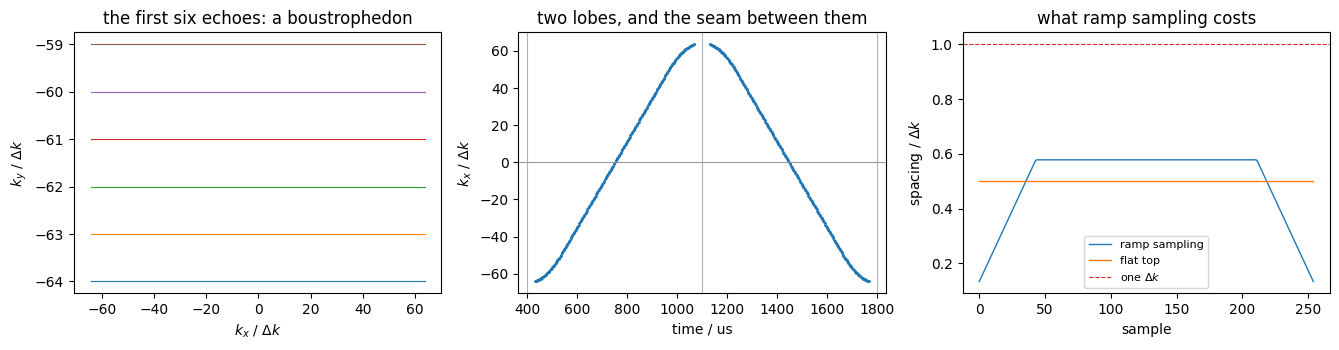

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
axes[0].plot(nominal.reshape(3, NY, -1)[0][:6].T / DK_X,
             nominal.reshape(3, NY, -1)[1][:6].T / DK_Y, lw=0.8)
axes[0].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$',
            title='the first six echoes: a boustrophedon')

t = sc.kspace(sc.LogicBlock('one').add(0.0, epi(lines=[CENTER_LINE, CENTER_LINE + 1])), opts)
axes[1].plot(t['t_adc'] * 1e6, t['k_adc'][0] / DK_X, '.', ms=2)
for edge in (0, 1, 2):
    axes[1].axvline((epi.winder_s + edge * epi.echo_spacing_s) * 1e6, color='0.7', lw=0.8)
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set(xlabel='time / us', ylabel='$k_x$ / $\\Delta k$',
            title='two lobes, and the seam between them')

axes[2].plot(np.diff(epi.k_read_per_m) / DK_X, lw=1.0, label='ramp sampling')
axes[2].plot(np.diff(probe(ramp_sampling=False).k_read_per_m) / DK_X, lw=1.0, label='flat top')
axes[2].axhline(1.0, color='C3', lw=0.8, ls='--', label='one $\\Delta k$')
axes[2].set(xlabel='sample', ylabel='spacing / $\\Delta k$', title='what ramp sampling costs')
axes[2].legend(fontsize=8)
fig.tight_layout()

---
## What this notebook established

| | |
|---|---|
| **`T = 2·guard + N·dwell`, exactly** | the two polarities then sample one k grid rather than two half a raster apart, and the reverse echo's samples are the forward echo's reversed |
| **the blip on the zero crossing, with `sc.barrier()` at the seam** | otherwise the compiler splits every readout lobe in the train, and the only report of it is a merge warning naming the readout axis |
| **one merge warning on the blip axis is expected** | the two halves of each split blip, summed back together — reported instead of hidden |
| **`k = 0` is a *sample*, not a moment** | at `pre_echo_samples` forward and its mirror reverse, which is what `echo_sample` exists to stop five callers writing out |
| **oversampling is free** | identical lobe, guard, peak and bandwidth per reconstructed pixel — and it is what brings the worst sample gap below one `Δk` |
| **ramp sampling is not a bandwidth trick** | 19 % off the echo spacing, bought with a higher peak, paid for with a non-uniform `k_read_per_m` |
| **`blip_lines` prices an ordering** | 700 µs at one line, and half as much again at the 126 a centric shot steps, which no table of integers carries on its own |
| **parallel imaging adds nothing to the readout** | `blip_lines=R`, `lines` anchored on the centre, and `R` more `build` calls for the ACS — with `reference=` the only new argument |
| **the spoiler rewinds as well as spoils** | `area = spoil_area − m0` with `m0` measured off the block just built, and the duration designed for the worst table so TR does not move with the ordering |

What none of it can say is what any of this **costs the magnetisation** — the ghost, the
distortion, and whether the reconstruction gets the object back.
[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) measures those.